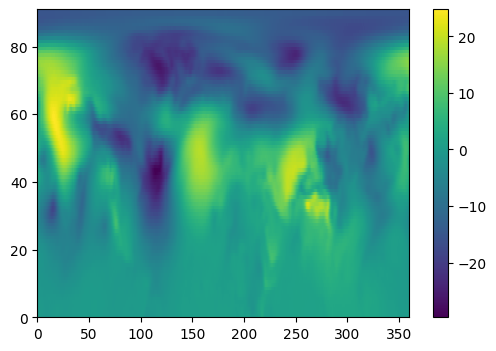

[]

In [ ]:
import torch
import patcher
import os
from matplotlib import pyplot as plt

context = patcher.Context('database', 1)

os.makedirs('images/database_test', exist_ok=True)

def draw(request, filename, method='load'):
    x = patcher.load(context, [request]) if method == 'load' else patcher.load_climate(context, [request])
    x = x[0]
    x = x[tuple([-1] * (x.dim() - 2) + [slice(None), slice(None)])]
    plt.figure(figsize=(6, 4))
    if method == 'load':
        if 'lsm' in filename:
            plt.pcolormesh(x, vmin=0, vmax=1)
        else:
            plt.pcolormesh(x)#, vmin=-15, vmax=15)
    else:
        plt.pcolormesh(x)
    plt.colorbar()
    plt.savefig(f'images/database_test/{filename}.png')
    plt.show()
    plt.close()

draw(patcher.Request('inm_ps', 0, 0, '19910201', 360, 91, 1, 1, 1, 2), 'inm_ps_global_full_res')
!!! #+ 'load_climate'

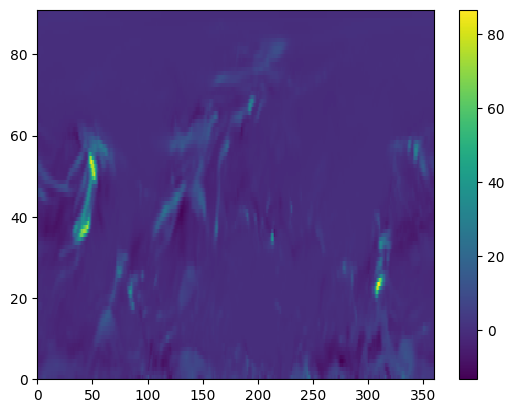

In [25]:
prec_anom = patcher.load(context, [patcher.Request('inm_prec', 0, 0, '19910201', 360, 91, 1, 1, 1, 2)])
prec_clim = patcher.load_climate(context, [patcher.Request('inm_prec', 0, 0, '19910201', 360, 91, 1, 1, 1, 2)])
x = prec_anom+prec_clim
x = x[0]
x = x[tuple([-1] * (x.dim() - 2) + [slice(None), slice(None)])]
plt.pcolormesh(x)   
plt.colorbar()

In [2]:
draw(patcher.Request('t2m', 0, 0, '19800101', 1440, 361, 1, 1, 1), 'era')
draw(patcher.Request('t2m', 0, 0, '19800101', 1440 // 4, 361 // 4 + 1, 1, 4, 1), 'era_1regional')
draw(patcher.Request('t2m', 0, 0, '19800101', 1440 // 16, 361 // 16 + 1, 1, 16, 1), 'era_2global')
draw(patcher.Request('t2m', 720, 0, '19800101', 1440, 361, 1, 1, 1), 'era_shifted_lon')
draw(patcher.Request('t2m', 0, 90, '19800101', 1440, 361, 1, 1, 1), 'era_shifted_lat')
draw(patcher.Request('t2m', 0, -90, '19800101', 1440, 361, 1, 1, 1), 'era_shifted_lat_negative')
draw(patcher.Request('t2m', -70, 200, '19800101', 507, 99, 1, 1, 1), 'era_cropped')
draw(patcher.Request('t2m', 0, 0, '20260430', 1440, 361, 1, 1, 1), 'era_last')
draw(patcher.Request('t2m', 0, 0, '20260401', 1440, 361, 30, 1, 1), 'era_last_time_size')
draw(patcher.Request('t2m', 0, 0, '19800101', 1440, 361, 1, 1, 30), 'era_aggregated')
draw(patcher.Request('t2m', 0, 0, '19910101', 1440, 361, 1, 1, 365*30 + 8), 'era_aggregated_large') # Должен быть 0 или очень близко
draw(patcher.Request('t2m', 0, 0, '19800101', 1440, 361, 1, 1, 1), 'era_climate', 'load_climate')
draw(patcher.Request('t2m', 0, 0, '19800101', 1440 // 4, 361 // 4 + 1, 1, 4, 1), 'era_climate_1regional', 'load_climate')
draw(patcher.Request('t2m', 0, 0, '19800101', 1440 // 16, 361 // 16 + 1, 1, 16, 1), 'era_climate_2global', 'load_climate')
draw(patcher.Request('t2m', 0, 0, '19800101', 1440, 361, 1, 1, 30), 'era_aggregate_climate', 'load_climate')

draw(patcher.Request('inm_t2m', 0, 0, '19920101', 360, 91, 1, 1, 1, 1), 'forecast')
draw(patcher.Request('inm_t2m', 0, 0, '20250101', 360, 91, 1, 1, 1, 1), 'forecast_operative')
draw(patcher.Request('inm_t2m', 0, 0, '19920101', 360, 91, 1, 1, 1, 2), 'forecast_null') # Должен быть пустым
draw(patcher.Request('inm_t2m', 0, 0, '19920101', 360 // 4, 91 // 4 + 1, 1, 4, 1, 1), 'forecast_1global')
draw(patcher.Request('inm_t2m', 0, 0, '19920101', 360, 91, 1, 1, 1, 1), 'forecast_climate', 'load_climate')
draw(patcher.Request('inm_t2m', 0, 0, '19920101', 360, 91, 1, 1, 30, 1), 'forecast_aggregated')

draw(patcher.Request('lsm', 0, 0, '19800101', 1440, 361, 1, 1, 1), 'lsm')
draw(patcher.Request('lsm', 0, 0, '19800101', 1440, 361, 1, 1, 30), 'lsm_aggregated')
draw(patcher.Request('lsm', 0, 0, '19800101', 1440, 361, 1, 1, 1), 'lsm_climate', 'load_climate') # Должны быть нули

In [3]:
from database import PatchDataset
from matplotlib import pyplot as plt

ds = PatchDataset(['t2m', 'lsm', 'inm_t2m', 'lat', 'lon', 'year', 'day', 'inm_lead_time'],
    ('19910101', '20201231'), 1000, batch_size=8, era_scales=[
    {'id': 'local', 'xSize': 16, 'ySize': 16, 'tSize': 7, 'xyStep': 1, 'tStep': 1},
    {'id': 'regional', 'xSize': 16, 'ySize': 16, 'tSize': 6, 'xyStep': 4, 'tStep': 7},
    {'id': 'global', 'xSize': 16, 'ySize': 16, 'tSize': 4, 'xyStep': 16, 'tStep': 30},
], inm_scales=[
    {'id': 'regional', 'xSize': 16, 'ySize': 16, 'tSize': 6, 'xyStep': 1, 'tStep': 1},
    {'id': 'global', 'xSize': 16, 'ySize': 16, 'tSize': 4, 'xyStep': 4, 'tStep': 7},
])

x = ds[0]

for key in x.keys():
    print(key, x[key].shape)

t2m_local torch.Size([8, 7, 16, 16])
t2m_regional torch.Size([8, 6, 16, 16])
t2m_global torch.Size([8, 4, 16, 16])
lsm_local torch.Size([8, 7, 16, 16])
lsm_regional torch.Size([8, 6, 16, 16])
lsm_global torch.Size([8, 4, 16, 16])
inm_t2m_regional torch.Size([8, 10, 6, 16, 16])
inm_t2m_global torch.Size([8, 10, 4, 16, 16])
lat_local torch.Size([8, 16])
lat_regional torch.Size([8, 16])
lat_global torch.Size([8, 16])
lon_local torch.Size([8, 16])
lon_regional torch.Size([8, 16])
lon_global torch.Size([8, 16])
year_local torch.Size([8, 7])
year_regional torch.Size([8, 6])
year_global torch.Size([8, 4])
day_local torch.Size([8, 7])
day_regional torch.Size([8, 6])
day_global torch.Size([8, 4])
inm_lead_time_regional torch.Size([8, 6])
inm_lead_time_global torch.Size([8, 4])


In [4]:
for level in ['local', 'regional', 'global']:
    for key in ['lon', 'lat', 'year', 'day']:
        print(f'{key}_{level}', x[f'{key}_{level}'][0, ...])
print('inm_lead_time_regional', x['inm_lead_time_regional'][0, ...])
print('inm_lead_time_global', x['inm_lead_time_global'][0, ...])

lon_local tensor([169.0000, 169.2500, 169.5000, 169.7500, 170.0000, 170.2500, 170.5000,
        170.7500, 171.0000, 171.2500, 171.5000, 171.7500, 172.0000, 172.2500,
        172.5000, 172.7500])
lat_local tensor([67.5000, 67.7500, 68.0000, 68.2500, 68.5000, 68.7500, 69.0000, 69.2500,
        69.5000, 69.7500, 70.0000, 70.2500, 70.5000, 70.7500, 71.0000, 71.2500])
year_local tensor([2007., 2007., 2007., 2007., 2007., 2007., 2007.])
day_local tensor([133., 134., 135., 136., 137., 138., 139.])
lon_regional tensor([163., 164., 165., 166., 167., 168., 169., 170., 171., 172., 173., 174.,
        175., 176., 177., 178.])
lat_regional tensor([61., 62., 63., 64., 65., 66., 67., 68., 69., 70., 71., 72., 73., 74.,
        75., 76.])
year_regional tensor([2007., 2007., 2007., 2007., 2007., 2007.])
day_regional tensor([ 98., 105., 112., 119., 126., 133.])
lon_global tensor([136., 140., 144., 148., 152., 156., 160., 164., 168., 172., 176., 180.,
        184., 188., 192., 196.])
lat_global tensor([36

In [5]:
def draw_red_square(data, N):
    center_y, center_x = data.shape[0] / 2, data.shape[1] / 2
    y_start = center_y - N / 2
    x_start = center_x - N / 2

    rect = plt.Rectangle((x_start, y_start), N, N, linewidth=1, edgecolor='red', facecolor='none')
    plt.gca().add_patch(rect)

# несовпадают из-за разных осреднений по времени и это нормально
plt.pcolormesh(x['t2m_local'][0, 0, :, :])
plt.savefig(f'../images/database_test/database_t2m_local.png')
plt.close()

plt.pcolormesh(x['t2m_regional'][0, 0, :, :])
plt.savefig(f'../images/database_test/database_t2m_regional.png')
plt.close()

plt.pcolormesh(x['t2m_global'][0, 0, :, :])
plt.savefig(f'../images/database_test/database_t2m_global.png')
plt.close()

plt.pcolormesh(x['lsm_local'][0, 0, :, :])
plt.savefig(f'../images/database_test/database_lsm_local.png')
plt.close()

plt.pcolormesh(x['lsm_regional'][0, 0, :, :])
draw_red_square(x['lsm_regional'][0, 0, :, :], 4)
plt.savefig(f'../images/database_test/database_lsm_regional.png')
plt.close()

plt.pcolormesh(x['lsm_global'][0, 0, :, :])
draw_red_square(x['lsm_global'][0, 0, :, :], 4)
draw_red_square(x['lsm_global'][0, 0, :, :], 1)
plt.savefig(f'../images/database_test/database_lsm_global.png')
plt.close()

plt.pcolormesh(x['inm_t2m_regional'][0, 0, 0, :, :])
plt.savefig(f'../images/database_test/database_inm_t2m_regional.png')
plt.close()

plt.pcolormesh(x['inm_t2m_global'][0, 0, 0, :, :])
plt.savefig(f'../images/database_test/database_inm_t2m_global.png')
plt.close()

In [6]:
# speed test
from tqdm.notebook import tqdm

for x in tqdm(ds.loader):
    pass

  0%|          | 0/1000 [00:00<?, ?it/s]